# Can local Clef replace a frontier LLM judge?

A decision model returns a typed score instead of generated text, which promises cheap, parse-free judging. We test that on **factual consistency of fixed summaries**, comparing Ollama-hosted Clef (27B, Q4_K_M) with Claude Opus 5.5 and Sonnet 5.5 through Snowflake Cortex. We are evaluating the judges, not asking them to write summaries.

## What this run found

**For offline scoring, the Claude judges ranked summaries more like the experts. For online guardrails, Clef is the stronger candidate: far cheaper per call, no output to parse, and calibration close to Claude's.**

| Question | Finding in the saved run |
| --- | --- |
| Is Clef cheaper? | Yes, by a wide margin. Pricing the measured tokens at published list rates: about **$0.20 per 1,000 judgments** for hosted Clef versus **$5.43 (Opus)** and **$3.70 (Sonnet)**, so roughly 28x and 19x. Our local calls carried no API charge at all, but local hardware cost is unmeasured. |
| Is Clef faster? | **Not in this deployment.** Median 4.55 s versus 3.40 s (Opus) and 2.45 s (Sonnet), though its p95 of 5.89 s beat Opus's 17.60 s. Cloudflare reports 209 ms median for hosted Clef, so quantized local inference, not the model class, is the bottleneck here. |
| Does Clef agree with humans? | Less closely. MAE 0.134 versus 0.087 and 0.089; Spearman 0.525 versus 0.653 and 0.625. The gap is in **ranking resolution**: 62% of its scores land within 0.10 of the expert rating, against 79% and 78%. |
| Is Clef well-calibrated? | **Yes, roughly as well as Claude.** Count-weighted calibration error 0.074 versus 0.060 and 0.064; all three skew slightly low. |
| Is Clef repeatable? | Identical scores across all 81 complete shared three-trial cohorts. Consistency is not correctness. |
| Does it ever fail? | Clef returned 300 valid scores from 300 calls. The hosted judges lost 37 calls to one HTTP 503 and expired Snowflake sessions, which are serving failures rather than bad judgments. |

These findings describe the **bundled October 8, 2026 snapshot**: 100 held-out summaries from 20 articles, three trials per judge, 900 scheduled judgments. Quality comparisons use 281 successful matched example/trial pairs. This is one task, one rubric, and one local quantization, not a general model leaderboard.

Below: the evidence for each row, a worked `block_output` guardrail on the recorded scores, cost estimates from the measured token counts, and which alternative decision models to try next. Replaying with `RUN_LIVE = False` makes no model calls. The optional live cells collect a new paid run; **the written findings describe the bundled snapshot and must be revised if you re-measure**.

TruLens `Metric`, `Jury.repeated`, `AlignmentReport`, `CrossModelAlignmentReport`, `Jury`, and `block_output` do the scoring, repeatability, alignment, and guardrail work. Two small adapters supply the Ollama System One and Cortex Messages transports.

In [33]:
import json
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
from trulens.benchmark import AlignmentReport
from trulens.benchmark.cross_model_alignment import CrossModelAlignmentReport
from trulens.core import Metric
from trulens.feedback import Jury

RUN_LIVE = False
N_EXAMPLES = 100
N_TRIALS = 3
THRESHOLD = 0.75

example_dir = Path.cwd()
if example_dir.name != "clef_judge_comparison":
    example_dir /= (
        "examples/expositional/models/local_and_OSS_models/"
        "clef_judge_comparison"
    )
snapshot_path = example_dir / "results_snapshot.json"

## Optional live evaluation

Leave `RUN_LIVE=False` to inspect saved results. Live mode downloads the pinned public SummEval dataset, uses article-disjoint splits, warms local Clef, and makes 900 judgments through `Metric(Jury.repeated(...))`. Each model's repeated calls run serially so adapter timings remain per-call. Configure `SNOWFLAKE_CONNECTION_NAME` and install Clef in Ollama first.

`Jury.repeated` returns native `reliability.*` metadata. No temperature override is supported by Clef or these Claude configurations; observed variation is serving/model nondeterminism, and a zero flip rate is not proof of general stability.

In [34]:
if RUN_LIVE:
    import hashlib
    import io
    import urllib.request

    import numpy as np

    dataset_url = (
        "https://huggingface.co/datasets/mteb/summeval/resolve/"
        "bfc121155064afa2d81b5505682ffc0d96f4334c/data/"
        "test-00000-of-00001-35901af5f6649399.parquet"
    )
    with urllib.request.urlopen(dataset_url, timeout=60) as response:
        payload = response.read()
    assert hashlib.sha256(payload).hexdigest() == (
        "7ff6f3f4d044223bd6922c5434d27bf28473950346fcfc2a3b7352c19163690e"
    )
    source = pd.read_parquet(io.BytesIO(payload))
    article_ids = sorted(source.id.astype(str))
    np.random.default_rng(42).shuffle(article_ids)
    held_out_ids = set(article_ids[int(len(article_ids) * 0.8) :])
    golden = pd.DataFrame([
        {
            "example_id": f"{row.id}:M{index}",
            "article_id": str(row.id),
            "source": row.text,
            "summary": summary,
            "true_label": (float(label) - 1) / 4,
        }
        for row in source.itertuples()
        if str(row.id) in held_out_ids
        for index, (summary, label) in enumerate(
            zip(row.machine_summaries, row.consistency, strict=True)
        )
    ])
    golden = golden.sort_values("example_id").sample(
        N_EXAMPLES, random_state=42
    )
    display(golden[["example_id", "true_label"]].head())

In [35]:
if RUN_LIVE:
    import os
    import sys

    import httpx
    import snowflake.connector

    sys.path.insert(0, str(example_dir))
    from decision_judges import Clef
    from decision_judges import CortexMessages

    connection = snowflake.connector.connect(
        connection_name=os.environ["SNOWFLAKE_CONNECTION_NAME"]
    )
    cortex_host = os.environ.get("SNOWFLAKE_HOST", connection.host)
    cortex_client = httpx.Client(base_url=f"https://{cortex_host}", timeout=180)
    ollama_client = httpx.Client(base_url="http://localhost:11434", timeout=180)
    judges = {
        "clef": Clef(ollama_client),
        "opus": CortexMessages("claude-opus-5-5", connection, cortex_client),
        "sonnet": CortexMessages(
            "claude-sonnet-5-5", connection, cortex_client
        ),
    }
    first = golden.iloc[0]
    judges["clef"].score(first.source, first.summary)
    judges["clef"].calls.clear()  # Exclude the explicit warm-up.
    metrics = {
        name: Metric(
            implementation=Jury.repeated(
                judge,
                method="score",
                n_trials=N_TRIALS,
                aggregation="median",
                threshold=THRESHOLD,
                max_workers=1,
            ),
            name=f"{name} consistency",
        )
        for name, judge in judges.items()
    }

In [36]:
if RUN_LIVE:
    live_results = []
    try:
        for row in golden.itertuples():
            for name, metric in metrics.items():
                before = len(judges[name].calls)
                try:
                    score, reliability = metric(
                        source=row.source, summary=row.summary
                    )
                except Exception as error:
                    score = None
                    reliability = {"error_type": type(error).__name__}
                live_results.append({
                    "example_id": row.example_id,
                    "article_id": row.article_id,
                    "true_label": row.true_label,
                    "judge": name,
                    "score": score,
                    **reliability,
                    "calls": judges[name].calls[before:],
                })
        pd.DataFrame(live_results).to_json(
            example_dir / "live_results.json", orient="records", indent=2
        )
    finally:
        ollama_client.close()
        cortex_client.close()
        connection.close()
    display(pd.DataFrame(live_results).head())

In [37]:
if not RUN_LIVE:
    snapshot = json.loads(snapshot_path.read_text())
    metadata = snapshot["metadata"]
    attempts = pd.DataFrame(**snapshot["attempts"])
else:
    # Analyze the new run, without merging it with the bundled results.
    fresh = []
    for result in live_results:
        for trial, call in enumerate(result["calls"]):
            fresh.append({
                "example_id": result["example_id"],
                "article_id": result["article_id"],
                "true_label": result["true_label"],
                "name": result["judge"],
                "repeat": trial,
                "phase": "measurement",
                "status": call["status"],
                "score": call.get("score"),
                "latency_seconds": call["seconds"],
                "usage": call.get("usage"),
            })
    attempts = pd.DataFrame(fresh)
    metadata = {
        "examples": len(golden),
        "repeats": N_TRIALS,
        "scheduled_judgments": len(golden) * N_TRIALS * len(judges),
        "run_started_utc": "Current live execution",
        "calibration_note": "Ordinal score alignment; no held-out fitting.",
        "cost_note": "Cortex USD unknown; local hardware/electricity unmeasured.",
        "models": {
            name: {
                "model": judge.model_engine,
                "quantization": "not recorded" if name == "clef" else None,
                "effort": None if name == "clef" else "medium",
                "parser": "typed score"
                if name == "clef"
                else "TruLens generate_score",
            }
            for name, judge in judges.items()
        },
    }

measured = attempts[attempts["phase"] == "measurement"].copy()
print(f"Run: {metadata['run_started_utc']}")
print(
    f"{metadata['examples']} summaries; {metadata['repeats']} trials; "
    f"{metadata['scheduled_judgments']} scheduled judgments"
)
print(metadata["calibration_note"])
display(
    pd.DataFrame(metadata["models"]).T[
        ["model", "quantization", "effort", "parser"]
    ]
)

Run: 2026-10-08T17:24:57.212233+00:00
100 summaries; 3 trials; 900 scheduled judgments
Ordinal score alignment, not probability calibration. No fitting on held-out labels.


,model,quantization,effort,parser
clef,clef:latest,Q4_K_M,NaN,NaN
opus,claude-opus-5-5,NaN,medium,single_terminal_score_object_v1
sonnet,claude-sonnet-5-5,NaN,medium,single_terminal_score_object_v1


## Speed and request reliability: two different questions

We first ask whether each deployment returned a usable judgment and how long successful calls took. All 300 scheduled calls per model count toward request reliability. Failed calls remain failures, never zero scores. Latency excludes the explicit Clef warm-up but includes any reloads during measurement and client/network time; it is not hardware-independent model speed.

The next table measures these operational properties. Later quality comparisons use only example/trial pairs successfully scored by every model, so a transport failure cannot make a judge appear less accurate.

,attempted,valid,success_rate,median_seconds,p95_seconds
name,,,,,
clef,300,300,1.000000,4.552517,5.894157
opus,300,281,0.936667,3.398143,17.600473
sonnet,300,282,0.940000,2.452110,4.847299


calls
name   status                          
clef   ok                           300
opus   http_503                       1
       ok                           281
       snowflake_session_expired     18
sonnet ok                           282
       snowflake_session_expired     18

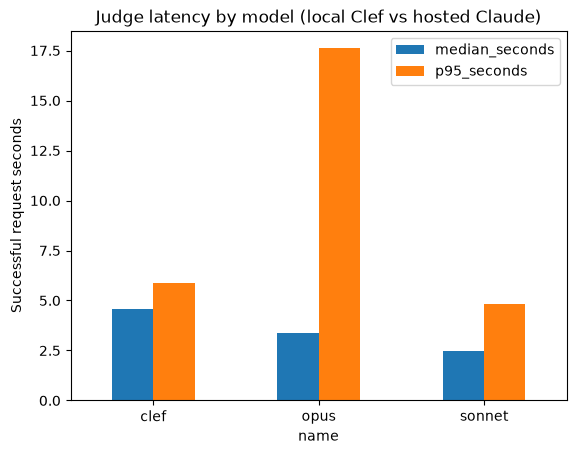

In [38]:
measured["valid"] = measured["status"].eq("ok") & measured["score"].between(
    0, 1
)
valid = measured[measured["valid"]]
operations = measured.groupby("name").agg(
    attempted=("valid", "size"), valid=("valid", "sum")
)
operations["success_rate"] = operations["valid"] / operations["attempted"]
operations["median_seconds"] = valid.groupby("name")["latency_seconds"].median()
operations["p95_seconds"] = valid.groupby("name")["latency_seconds"].quantile(
    0.95
)
display(operations)
display(measured.groupby(["name", "status"]).size().to_frame("calls"))
operations[["median_seconds", "p95_seconds"]].plot.bar(
    rot=0,
    ylabel="Successful request seconds",
    title="Judge latency by model (local Clef vs hosted Claude)",
)
plt.show()

### Clef was not faster here, and that is a deployment result

Clef's median successful call took **4.55 seconds**, versus **3.40 for Opus** and **2.45 for Sonnet**: about 1.34x and 1.86x as long. Its tail was better than Opus's, at **p95 5.89 seconds** versus **17.60**, though Sonnet had the lowest p95 at **4.85 seconds**. Local inference removed a remote API hop but did not make the median call faster on this machine. These distributions use each model's successful calls, not matched-pair timing or a controlled hardware comparison.

**Do not read this as the speed of decision models.** Cloudflare reports a 209 ms median for hosted Clef and 38.8 ms for Clef-flash, against 524 ms for Jev. Those are the vendor's own figures and are not reproduced here, but a roughly 20x gap points at this deployment, a Q4_K_M quantization of a 27B model on a laptop, rather than at the architecture. The non-autoregressive single-pass design is what should make these models fast; we did not give it suitable hardware.

**Clef completed all 300 calls; this is not evidence that the hosted models were weaker judges.** Opus returned 281 valid scores and Sonnet 282. One Opus request failed with HTTP 503, and each hosted model lost its final 18 calls to an expired Snowflake session. Those 36 authentication failures are a serving issue to fix before deployment, not reasoning or score-format errors. No failed call was retried or converted into a bad score.

For the quality analysis that follows, we keep only successful matched pairs. This avoids comparing different inputs across judges, but it cannot remove possible bias from the missing late-run observations.

## Human alignment: low error is not the whole story

SummEval expert consistency ratings are normalized from 1-5 to 0-1. **MAE** measures the average absolute gap from experts (lower is better); **Spearman correlation** measures whether judges rank summaries in the same order as experts (higher is better). The fixed pass threshold is 0.75, corresponding to 4 out of 5. A good rank correlation does not mean the same numerical threshold is safe for every judge.

The next tables compare identical successful example/trial pairs across models and show each trial separately. Multiple summaries from one article and repeated judgments are dependent observations; these descriptive results do not establish statistical significance. No prompt or calibrator was fitted on the held-out labels.

In [39]:
paired = valid.pivot(
    index=["example_id", "article_id", "repeat", "true_label"],
    columns="name",
    values="score",
)
paired = paired.reindex(columns=list(metadata["models"]))
paired = paired.dropna().reset_index()
print(f"Common successful example/trial pairs: {len(paired)}")
if paired.empty:
    raise ValueError("No complete panels; inspect the failure table first.")
reports = {
    (model, repeat): AlignmentReport(
        predicted_scores=rows[model].tolist(),
        true_labels=rows["true_label"].tolist(),
        examples=rows.to_dict(orient="records"),
        threshold=THRESHOLD,
    )
    for repeat, rows in paired.groupby("repeat")
    for model in metadata["models"]
}
trial_summaries = [
    report.to_dataframe()["summary"].assign(model=model, trial=repeat + 1)
    for (model, repeat), report in reports.items()
]
display(pd.concat(trial_summaries, ignore_index=True))
model_report = CrossModelAlignmentReport(
    names=list(metadata["models"]),
    scores=[paired[model].tolist() for model in metadata["models"]],
    expected=paired["true_label"].tolist(),
)
display(pd.DataFrame(model_report.ground_truth_metrics()).T)
display(
    pd.DataFrame(
        model_report.spearman,
        index=model_report.names,
        columns=model_report.names,
    )
)
labels = measured.drop_duplicates("example_id")["true_label"]
display(labels.describe().to_frame("expert_consistency"))

Common successful example/trial pairs: 281


,metric,value,model,trial
0,MAE,0.136294,clef,1
1,Spearman correlation,0.530017,clef,1
2,Kendall's tau,0.425274,clef,1
3,Cohen's kappa at 0.75,0.346774,clef,1
4,Brier score,0.036840,clef,1
5,AUC,0.869663,clef,1
6,MAE,0.085017,opus,1
7,Spearman correlation,0.668469,opus,1
8,Kendall's tau,0.623889,opus,1
9,Cohen's kappa at 0.75,0.562826,opus,1


,mae,spearman,kendall
clef,0.133924,0.524590,0.421670
opus,0.086892,0.653247,0.609148
sonnet,0.088968,0.624629,0.581644


,clef,opus,sonnet
clef,1.000000,0.718392,0.710382
opus,0.718392,1.000000,0.946188
sonnet,0.710382,0.946188,1.000000


,expert_consistency
count,100.000000
mean,0.910833
std,0.225125
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


### The hosted judges agreed more closely with experts

Across the **281 matched example/trial pairs**, Clef's MAE was **0.134** and Spearman correlation **0.525**, compared with **0.087 / 0.653 for Opus** and **0.089 / 0.625 for Sonnet**. Clef's absolute error was roughly 50% higher than either hosted judge's. Each trial shows the same direction, although the paired cohort shrinks from 99 and 100 summaries in the first two trials to 82 in the third after the session expires.

The sample is easy to flatter with MAE alone: **77 of the 100 summaries have the maximum expert rating**, and the mean label is 0.911. Predicting 1.0 for every matched row would produce an MAE of about 0.089, yet distinguish no good summaries from bad ones. Read the error, rank correlation, threshold diagnostics, and worst misses together rather than treating a small MAE as sufficient evidence of a useful judge.

**Next: do their numerical scores mean the same thing?** The native `AlignmentReport` plots below show the first trial (99 matched summaries); all three trials are summarized above. On the calibration chart, points on the diagonal match the experts' average rating in that score bin. The histograms and bin counts show where we actually have evidence.

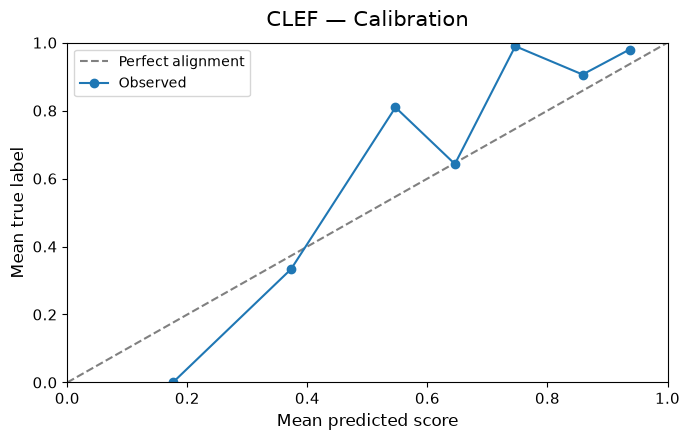

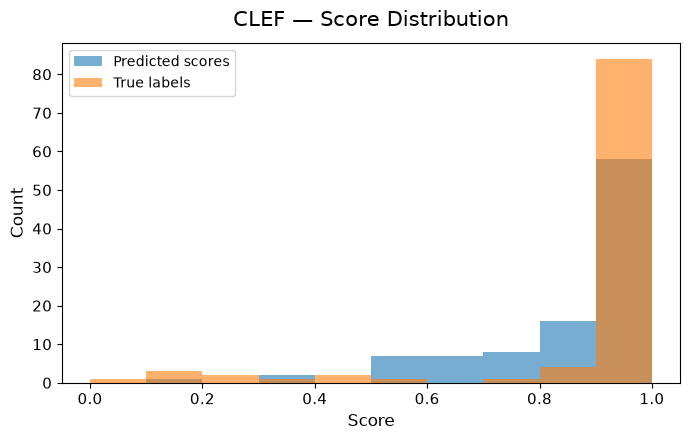

clef calibration bins, trial 1


,bin,bin_lower,bin_upper,count,mean_predicted_score,mean_true_label
0,0,0.0,0.1,0,NaN,NaN
1,1,0.1,0.2,1,0.175984,0.000000
2,2,0.2,0.3,0,NaN,NaN
3,3,0.3,0.4,2,0.372751,0.333333
4,4,0.4,0.5,0,NaN,NaN
5,5,0.5,0.6,7,0.546800,0.809524
6,6,0.6,0.7,7,0.645777,0.642857
7,7,0.7,0.8,8,0.746424,0.989583
8,8,0.8,0.9,16,0.858524,0.906250
9,9,0.9,1.0,58,0.936815,0.979885


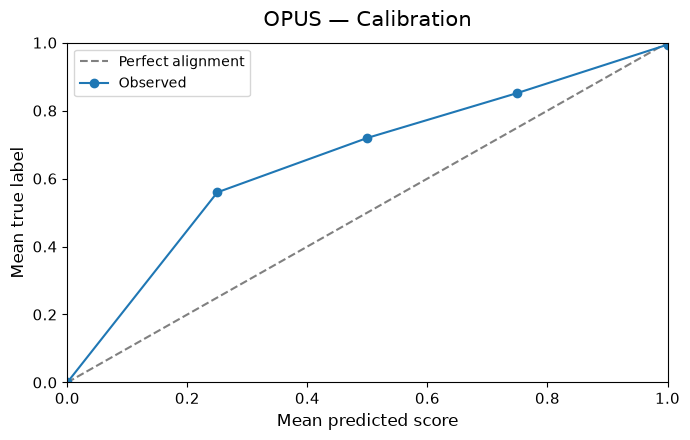

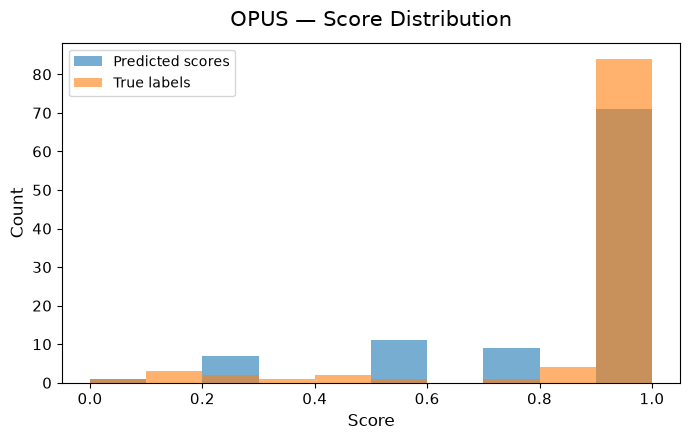

opus calibration bins, trial 1


,bin,bin_lower,bin_upper,count,mean_predicted_score,mean_true_label
0,0,0.0,0.1,1,0.00,0.000000
1,1,0.1,0.2,0,NaN,NaN
2,2,0.2,0.3,7,0.25,0.559524
3,3,0.3,0.4,0,NaN,NaN
4,4,0.4,0.5,0,NaN,NaN
5,5,0.5,0.6,11,0.50,0.719697
6,6,0.6,0.7,0,NaN,NaN
7,7,0.7,0.8,9,0.75,0.851852
8,8,0.8,0.9,0,NaN,NaN
9,9,0.9,1.0,71,1.00,0.994131


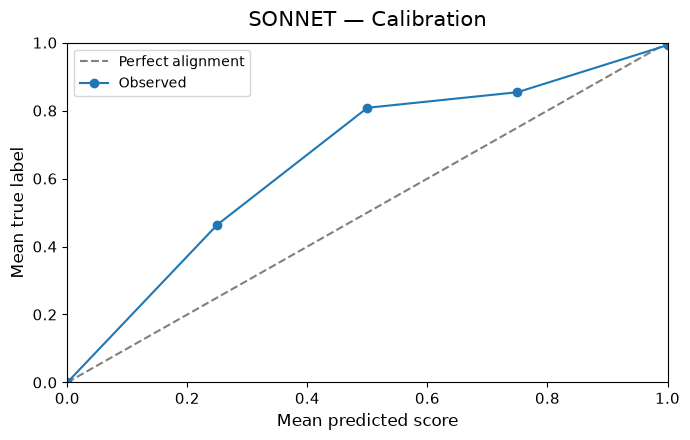

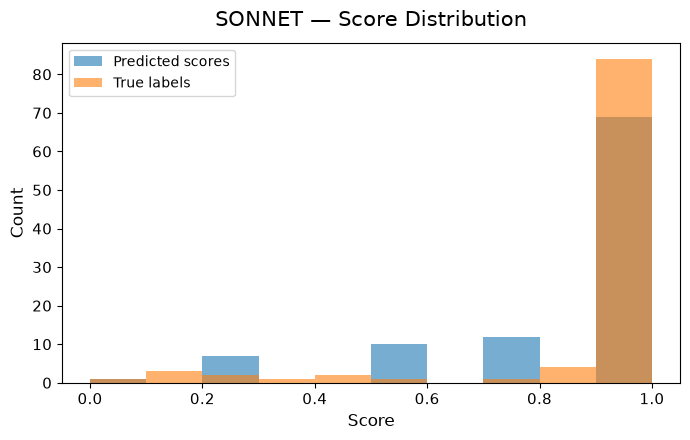

sonnet calibration bins, trial 1


,bin,bin_lower,bin_upper,count,mean_predicted_score,mean_true_label
0,0,0.0,0.1,1,0.00,0.000000
1,1,0.1,0.2,0,NaN,NaN
2,2,0.2,0.3,7,0.25,0.464286
3,3,0.3,0.4,0,NaN,NaN
4,4,0.4,0.5,0,NaN,NaN
5,5,0.5,0.6,10,0.50,0.808333
6,6,0.6,0.7,0,NaN,NaN
7,7,0.7,0.8,12,0.75,0.854167
8,8,0.8,0.9,0,NaN,NaN
9,9,0.9,1.0,69,1.00,0.992754


In [40]:
# Native plots for the first available trial; every trial is summarized above.
first_trial = int(paired["repeat"].min())
for model in metadata["models"]:
    figures = reports[(model, first_trial)].plot()
    for figure in figures.values():
        axis = figure.axes[0]
        # Name the judge on the figure itself so saved charts stay readable.
        axis.set_title(
            f"{model.upper()} — {axis.get_title()}", fontsize=15, pad=12
        )
        axis.xaxis.label.set_size(12)
        axis.yaxis.label.set_size(12)
        axis.tick_params(labelsize=11)
        figure.set_size_inches(7, 4.5)
        figure.tight_layout()
    plt.show()
    print(f"{model} calibration bins, trial {first_trial + 1}")
    display(reports[(model, first_trial)].to_dataframe()["calibration"])

In [ ]:
def calibration_error(report):
    """Count-weighted mean gap between predicted and expert scores."""
    bins = report.to_dataframe()["calibration"]
    filled = bins[bins["count"] > 0]
    gaps = (filled["mean_predicted_score"] - filled["mean_true_label"]).abs()
    return float((gaps * filled["count"]).sum() / filled["count"].sum())


calibration = pd.DataFrame([
    {
        "model": model,
        "weighted_calibration_error": calibration_error(
            reports[(model, first_trial)]
        ),
        "populated_bins": int(
            (
                reports[(model, first_trial)].to_dataframe()["calibration"][
                    "count"
                ]
                > 0
            ).sum()
        ),
        "mean_signed_gap": float((paired[model] - paired["true_label"]).mean()),
        "within_0.10": float(
            (paired[model] - paired["true_label"]).abs().le(0.10).mean()
        ),
        "within_0.25": float(
            (paired[model] - paired["true_label"]).abs().le(0.25).mean()
        ),
    }
    for model in metadata["models"]
]).set_index("model")
display(calibration)

,weighted_calibration_error,populated_bins,mean_signed_gap,within_0.10,within_0.25
model,,,,,
clef,0.073953,7,-0.066792,0.619217,0.829181
opus,0.059764,5,-0.051898,0.793594,0.889680
sonnet,0.063973,5,-0.051008,0.779359,0.889680


### Calibration verdict: Clef's scores are close to expert ratings

**Clef is reasonably calibrated on this data, and I overstated the opposite in an earlier draft of this notebook.** The count-weighted calibration error above is **0.074 for Clef, 0.060 for Opus, and 0.064 for Sonnet**, so the three judges are within roughly a point and a half of each other on a 0-1 scale. All three skew slightly low rather than high: mean signed gaps are -0.067, -0.052, and -0.051. On the calibration charts, points above the diagonal mean the judge rated those summaries lower than experts did, which is the dominant pattern for every model here.

**The real gap is resolution, not calibration.** Clef's bin averages sit close to the diagonal, yet it ranks individual summaries less like the experts: Spearman 0.525 versus 0.653 and 0.625. Per example, 62% of Clef's scores land within 0.10 of the expert rating, versus 79% for Opus and 78% for Sonnet. A judge can have well-placed bin averages while still mixing up which specific summary is better.

Two reading caveats. Clef returns a probability-weighted continuous score and populated seven bins, while Claude was prompted for an integer 1-5 and populated five; a continuous score can look smoother simply because it is not quantized. And the largest bin gaps sit in sparsely populated bins (7 to 11 summaries), where the expert mean is itself noisy. 'Calibration' here means agreement with expert ratings, not the probability that a summary is factually correct. No calibration mapping was trained, and these plots do not validate a production threshold.

In [42]:
for model in metadata["models"]:
    print(model, "largest absolute errors, first available trial")
    misses = reports[(model, first_trial)].to_dataframe()["worst_misses"]
    display(misses.head(5))

clef largest absolute errors, first available trial


,index,predicted_score,true_label,absolute_error,example_id,article_id,repeat,example_true_label,clef,opus,sonnet
0,26,0.916574,0.166667,0.749907,dm-test-02c955067d00f38b6978b805d5a8701a787f78...,dm-test-02c955067d00f38b6978b805d5a8701a787f78ac,0,0.166667,0.916574,0.75,0.75
1,51,0.881909,0.166667,0.715242,dm-test-2cfc33d01364162579f46b2764914a03a29453...,dm-test-2cfc33d01364162579f46b2764914a03a29453ce,0,0.166667,0.881909,0.25,0.25
2,56,0.519329,1.000000,0.480671,dm-test-4fb64a2298e18626db776fccf834be87388827...,dm-test-4fb64a2298e18626db776fccf834be87388827e0,0,1.000000,0.519329,0.25,0.25
3,80,0.502309,0.916667,0.414357,dm-test-97bbda7ec22a736cd174b51513c72a6372d13d...,dm-test-97bbda7ec22a736cd174b51513c72a6372d13d35,0,0.916667,0.502309,0.25,0.50
4,1,0.586416,1.000000,0.413584,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c06...,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c063f6,0,1.000000,0.586416,0.50,0.50


opus largest absolute errors, first available trial


,index,predicted_score,true_label,absolute_error,example_id,article_id,repeat,example_true_label,clef,opus,sonnet
0,15,0.25,1.000000,0.750000,cnn-test-e49792c337d3f4c13e22f710efa44cf6a4e59...,cnn-test-e49792c337d3f4c13e22f710efa44cf6a4e59aba,0,1.000000,0.659582,0.25,0.50
1,56,0.25,1.000000,0.750000,dm-test-4fb64a2298e18626db776fccf834be87388827...,dm-test-4fb64a2298e18626db776fccf834be87388827e0,0,1.000000,0.519329,0.25,0.25
2,80,0.25,0.916667,0.666667,dm-test-97bbda7ec22a736cd174b51513c72a6372d13d...,dm-test-97bbda7ec22a736cd174b51513c72a6372d13d35,0,0.916667,0.502309,0.25,0.50
3,26,0.75,0.166667,0.583333,dm-test-02c955067d00f38b6978b805d5a8701a787f78...,dm-test-02c955067d00f38b6978b805d5a8701a787f78ac,0,0.166667,0.916574,0.75,0.75
4,1,0.50,1.000000,0.500000,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c06...,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c063f6,0,1.000000,0.586416,0.50,0.50


sonnet largest absolute errors, first available trial


,index,predicted_score,true_label,absolute_error,example_id,article_id,repeat,example_true_label,clef,opus,sonnet
0,56,0.25,1.000000,0.750000,dm-test-4fb64a2298e18626db776fccf834be87388827...,dm-test-4fb64a2298e18626db776fccf834be87388827e0,0,1.000000,0.519329,0.25,0.25
1,74,0.25,0.916667,0.666667,dm-test-6c1341bedf92a304318545fbf1aad88651de79...,dm-test-6c1341bedf92a304318545fbf1aad88651de7909,0,0.916667,0.680519,0.50,0.25
2,26,0.75,0.166667,0.583333,dm-test-02c955067d00f38b6978b805d5a8701a787f78...,dm-test-02c955067d00f38b6978b805d5a8701a787f78ac,0,0.166667,0.916574,0.75,0.75
3,1,0.50,1.000000,0.500000,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c06...,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c063f6,0,1.000000,0.586416,0.50,0.50
4,15,0.50,1.000000,0.500000,cnn-test-e49792c337d3f4c13e22f710efa44cf6a4e59...,cnn-test-e49792c337d3f4c13e22f710efa44cf6a4e59aba,0,1.000000,0.659582,0.25,0.50


### Worst misses reveal what an average hides

Clef's largest first-trial miss scored a summary **0.917 when experts scored it 0.167**. That would pass our fixed 0.75 threshold despite the low expert rating. Clef is not simply 'too strict': although it assigns lower scores than experts to many high-rated summaries, it can also give a high score to a poorly rated one.

The hosted judges also made large errors. On one shared example both scored 0.25 against an expert score of 1.0. Stronger aggregate agreement is not permission to treat a judge as ground truth. The table retains public benchmark IDs so these disagreements can be traced back to the article and summary for review; this notebook does not adjudicate whether the model or the human label was right in each case.

## Repeatability, a median jury, and usage

Now we separate **stability** (does a judge repeat its score?) from **alignment** (does that score match experts?). We replay the recorded scores through native TruLens `Jury`; this makes no additional model calls. Repeated-call comparisons require all three trials to succeed for every model on a summary.

`reliability.score_std` measures the score spread. `reliability.flip_rate` measures the fraction of votes disagreeing with the majority pass/fail decision at 0.75, not the fraction of examples that flipped at least once. A model can change its numerical score without crossing that threshold.

The median panel combines Clef, Opus, and Sonnet on complete example/trial pairs. Its alignment is measured, but its live execution latency is not. The usage table counts only calls that reported usage; missing usage is not assumed to be free. After the tables, we interpret whether the extra calls bought better judgments and what we can say about cost.

In [43]:
class RecordedJudge:
    """Replay measured scores so native Jury analysis needs no new calls."""

    def __init__(self, name, score):
        self.model_engine = name
        self.value = score

    def score(self, **kwargs):
        return self.value


repeat_results = []
for model in metadata["models"]:
    for example_id, rows in paired.groupby("example_id"):
        if len(rows) != metadata["repeats"]:
            continue
        repeated = Jury(
            [
                RecordedJudge(model, score)
                for score in rows.sort_values("repeat")[model]
            ],
            method="score",
            max_workers=1,
            threshold=THRESHOLD,
        )
        _, reliability = repeated()
        repeat_results.append({
            "model": model,
            "example_id": example_id,
            **reliability,
        })
reliability = pd.DataFrame(repeat_results)
if not reliability.empty:
    display(reliability.groupby("model").size().to_frame("complete_cohorts"))
    display(
        reliability.groupby("model")[
            [
                "reliability.score_std",
                "reliability.flip_rate",
                "reliability.outcome_entropy",
            ]
        ].mean()
    )
else:
    print("No complete repeated-trial cohorts.")

jury_scores = []
for row in paired.to_dict(orient="records"):
    jury = Jury(
        [RecordedJudge(model, row[model]) for model in metadata["models"]],
        method="score",
        aggregation="median",
        threshold=THRESHOLD,
    )
    score, _ = jury()
    jury_scores.append(score)
jury_report = AlignmentReport(
    jury_scores, paired["true_label"].tolist(), threshold=THRESHOLD
)
display(jury_report.to_dataframe()["summary"])
usage = pd.DataFrame([
    {"model": row["name"], **row["usage"]}
    for row in measured.to_dict(orient="records")
    if isinstance(row.get("usage"), dict)
])
if not usage.empty:
    display(usage.groupby("model").sum(numeric_only=True))
    display(usage.groupby("model").size().to_frame("calls_with_usage"))
print(metadata["cost_note"])

,complete_cohorts
model,
clef,81
opus,81
sonnet,81


,reliability.score_std,reliability.flip_rate,reliability.outcome_entropy
model,,,
clef,0.000000,0.000000,0.000000
opus,0.005820,0.004115,0.011337
sonnet,0.013095,0.000000,0.000000


,metric,value
0,MAE,0.086497
1,Spearman correlation,0.637780
2,Kendall's tau,0.591895
3,Cohen's kappa at 0.75,0.500262
4,Brier score,0.034556
5,AUC,0.946852


,input_tokens,output_tokens,cache_read_input_tokens,cache_creation_input_tokens
model,,,,
clef,245334,0,0,0
opus,306942,14957,0,0
sonnet,308367,42794,0,0


,calls_with_usage
model,
clef,300
opus,281
sonnet,282


Cortex USD unknown. Local API charge excludes hardware/electricity.


### Stable judgments did not necessarily agree with humans

There are **81 summaries with complete three-trial cohorts for all three judges**. On those summaries, Clef returned identical scores (mean score standard deviation 0). Opus's mean standard deviation was 0.0058 and Sonnet's was 0.0131. Opus's mean majority-disagreement rate was 0.41%; Clef and Sonnet had no threshold disagreements. Sonnet's nonzero score variation alongside zero flips illustrates why both measures matter.

This establishes repeatability only for three calls under these serving settings, without a temperature override. It does not establish stability on other tasks or after model updates. Clef's larger human-alignment error shows why a consistently repeated answer can still be wrong.

**The median jury did not establish a useful improvement over Opus alone.** Its MAE was 0.0865 versus Opus's 0.0869, a tiny descriptive difference, while its Spearman correlation was lower (0.638 versus 0.653). A live panel needs all three judgments. These results do not justify that added inference work for this task, and no live-jury latency or dollar savings were measured.

## Cost: hosted Clef would be roughly 20-30x cheaper per judgment

Our Clef calls ran locally, so they carried **no provider API charge** but also no measurable bill. To get a comparable number, we price the **measured token counts** at published list rates. These are estimates on a hosted basis, not our actual invoice.

Rates checked 2026-10-08: hosted Clef on Cloudflare Workers AI is **$0.24 per million input tokens with no output charge** (Clef-flash is $0.09), because a decision model returns probabilities rather than generated text. Claude Opus 5.5 lists at **$4 input / $20 output** and Sonnet 5.5 at **$2 / $10** per million tokens. Two caveats matter: our Claude calls actually billed through **Snowflake Cortex**, whose rate for these models we did not obtain, and secondary sources report other hosted Clef rates (for example OpenRouter lists $0.042 per million input tokens), so treat the ratio as an order of magnitude rather than a quote.

,basis,judgments,run_usd,usd_per_1k_judgments,vs_clef_hosted
priced_as,,,,,
clef,Cloudflare Workers AI,300,0.0589,0.196,1.0
clef-flash,Workers AI (9B),300,0.0221,0.074,0.4
opus,Anthropic list,281,1.5269,5.434,27.7
sonnet,Anthropic list,282,1.0447,3.705,18.9


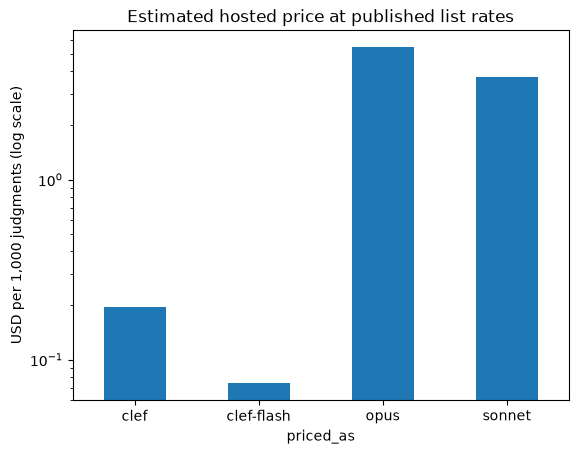

In [44]:
# List prices checked 2026-10-08, in USD per million tokens. Hosted Clef is
# input-only on Workers AI; Claude rates are Anthropic's published API list.
# Our Claude calls actually billed through Snowflake Cortex, whose rate for
# these models we did not obtain, so these are substitution estimates.
RATES = {
    "clef": {"input": 0.24, "output": 0.0, "basis": "Cloudflare Workers AI"},
    "clef-flash": {"input": 0.09, "output": 0.0, "basis": "Workers AI (9B)"},
    "opus": {"input": 4.0, "output": 20.0, "basis": "Anthropic list"},
    "sonnet": {"input": 2.0, "output": 10.0, "basis": "Anthropic list"},
}
priced = usage.groupby("model").sum(numeric_only=True)
priced["judgments"] = usage.groupby("model").size()
estimates = []
for model, row in priced.iterrows():
    for name in [model] + (["clef-flash"] if model == "clef" else []):
        rate = RATES[name]
        total = (
            row["input_tokens"] / 1e6 * rate["input"]
            + row["output_tokens"] / 1e6 * rate["output"]
        )
        estimates.append({
            "priced_as": name,
            "basis": rate["basis"],
            "judgments": int(row["judgments"]),
            "run_usd": round(total, 4),
            "usd_per_1k_judgments": round(total / row["judgments"] * 1_000, 3),
        })
estimates = pd.DataFrame(estimates).set_index("priced_as")
estimates["vs_clef_hosted"] = (
    estimates["usd_per_1k_judgments"]
    / estimates.loc["clef", "usd_per_1k_judgments"]
).round(1)
display(estimates)
estimates["usd_per_1k_judgments"].plot.bar(
    rot=0,
    logy=True,
    ylabel="USD per 1,000 judgments (log scale)",
    title="Estimated hosted price at published list rates",
)
plt.show()

**At list rates this workload is about $0.06 priced as hosted Clef, $1.53 as Opus, and $1.04 as Sonnet.** Per 1,000 judgments that is roughly **$0.20, $5.43, and $3.70**: Opus about 28x and Sonnet about 19x hosted Clef. Clef-flash would be about $0.07 per 1,000. The gap comes from two things, not just the headline rate: Clef's input rate is 8-17x lower, and it bills no output tokens at all, while Claude's thinking tokens land in the billed output column (Sonnet emitted 42,794 output tokens here versus Opus's 14,957).

The ratio holds only for input-heavy judging, where each call sends a full article and returns one score. It does not transfer to generation workloads. Cost per judgment is also not cost per *useful* judgment: at a 0.75 threshold Clef disagrees with experts more often, so the gap narrows once you price the review work its errors create. Local execution has no per-call fee but needs the 27B model resident in memory, which is only economical at sustained volume.

## Online evaluation: the case for Clef is strong, with one caveat

Offline scoring and online evaluation reward different things. Offline, you want the closest possible agreement with human labels and you can afford a slow, expensive judge. Online, a guardrail runs on **every** request, so per-call price and tail latency dominate, and the only output you use is a pass/fail decision at a threshold.

**On that scoring, a decision model is the better fit:**

- **Price per call.** About 20-30x cheaper per judgment at list rates, and the gap grows with volume.
- **No output parsing.** Clef returns a typed score, so there is no free-text reply that can arrive unparsable. Our 300 Clef calls produced 300 valid scores; the generative path needed a strict parser, and in earlier development runs Claude returned prose that had to be rejected.
- **Predictable tail.** Clef's p95 was 5.89 s against Opus's 17.60 s. For a blocking guardrail the tail is the user-visible number.
- **Only the threshold decision is consumed.** A guardrail does not need a well-ordered 1-5 rating, just a reliable side of the line, and Clef's calibration error is close to Claude's.

**The caveat is our measured latency: 4.55 s at the median is too slow to block a live request.** That is a property of this deployment, not of decision models. Cloudflare reports 209 ms median for hosted Clef and 38.8 ms for Clef-flash, versus 524 ms for Jev; those are the vendor's own figures, not reproduced here, but the ~20x gap against our local Q4_K_M run on a laptop points at quantized local inference rather than the model class. **Before using Clef as an inline guardrail, measure p95 on the deployment you will actually run, hosted or local on a GPU.**

The cell below turns the recorded Clef scores into a guardrail decision and asks the operational question: at a 0.75 threshold, how many responses would it block, and what do the expert labels say about them? It makes no model calls.

In [48]:
# Replay the recorded first-trial scores through a block_output guardrail.
from trulens.core.guardrails.base import block_output

online = paired[paired["repeat"] == first_trial].reset_index(drop=True)
recorded = dict(zip(online["example_id"], online["clef"], strict=True))
FALLBACK = "Withheld for human review."


def recorded_clef_score(summary: str) -> float:
    """Return the measured Clef score for this summary; no model call."""
    return recorded[summary]


clef_gate = Metric(
    implementation=recorded_clef_score,
    name="clef consistency",
    higher_is_better=True,
)


class SummaryService:
    """A guarded response path; the summary id stands in for live output."""

    @block_output(
        feedback=clef_gate, threshold=THRESHOLD, return_value=FALLBACK
    )
    def respond(self, example_id: str) -> str:
        return example_id


service = SummaryService()
decisions = pd.DataFrame([
    {
        "example_id": row.example_id,
        "clef_score": row.clef,
        "served": service.respond(row.example_id) != FALLBACK,
        "expert_pass": row.true_label >= THRESHOLD,
    }
    for row in online.itertuples()
])
matrix = pd.crosstab(
    decisions["served"], decisions["expert_pass"], margins=True
)
served = decisions[decisions["served"]]
blocked = decisions[~decisions["served"]]
display(matrix)
display(
    pd.DataFrame([
        {
            "responses": len(decisions),
            "blocked": len(blocked),
            "blocked_share": round(len(blocked) / len(decisions), 3),
            "served_that_experts_failed": int((~served["expert_pass"]).sum()),
            "blocked_that_experts_passed": int(blocked["expert_pass"].sum()),
            "usd_per_1k_online_checks": estimates.loc[
                "clef", "usd_per_1k_judgments"
            ],
            "p95_seconds_this_deployment": round(
                operations.loc["clef", "p95_seconds"], 2
            ),
        }
    ])
)

Metric implementation <function recorded_clef_score at 0x14b9056c0> cannot be serialized: Module __main__ is not importable. This may be ok unless you are using the deferred feedback mode.


expert_pass,False,True,All
served,,,
False,7,15,22
True,3,74,77
All,10,89,99


,responses,blocked,blocked_share,served_that_experts_failed,blocked_that_experts_passed,usd_per_1k_online_checks,p95_seconds_this_deployment
0,99,22,0.222,3,15,0.196,5.89


### Reading the guardrail result

At the 0.75 threshold Clef blocked **22 of 99 responses (22%)**. Of those, experts had rated **15 as acceptable**, so they were withheld unnecessarily. Three responses that experts rated as failing were served anyway. That is the trade this guardrail makes on this data: it catches most of the genuinely bad summaries, at the price of blocking roughly one in six acceptable ones.

Whether that is a good deal is an application decision, not a model fact. If the fallback is cheap, such as routing to review, over-blocking is tolerable. If it is a refusal shown to a user, 15% unnecessary blocks is likely unacceptable and the threshold needs to move. **0.75 is the fixed rubric threshold we used for scoring throughout, not a tuned operating point**: it was never selected on development data, and the expert labels used to judge it here are the same held-out labels, so these rates are descriptive rather than a validated configuration.

The mechanism is what transfers. `block_output` wraps the response path, evaluates a `Metric`, and substitutes a fallback when the score falls below the threshold, emitting a guardrail span either way. Swapping `recorded_clef_score` for the live `Clef.score` adapter turns this into a real online guardrail; everything else stays the same. Pick the threshold on a development split, confirm it on held-out data, and re-measure p95 on the deployment you intend to run.

## Would another decision model do better?

Clef is not the only option, and nothing here suggests it is the ceiling for this class of model. Four candidates worth testing with this same notebook:

- **Clef-flash (9B, Cloudflare).** Cheaper ($0.09 per million input tokens) and reported at 38.8 ms median. Cloudflare's own figures also show it dropping sharply on harder intent sets, for example 66.77 against Clef's 97.43 macro-F1 on CLINC150 with out-of-scope detection, so it may trade away exactly the discrimination this task needs.
- **Jev (TypeSafe AI).** The original System One model and the reference implementation of this API. Proprietary weights, 32K context, text-only, and reported slower than Clef, but a lower input rate.
- **Nimble (Bespoke Labs)** and **Tev1 (Together AI)**, the other decision models in Ollama 0.35.
- **A fine-tuned Clef.** Cloudflare offers reinforcement-learning fine-tuning on your own traffic. Our weakness was ranking resolution on one rubric, which is the kind of gap task-specific tuning targets.

Treat the published comparisons carefully. Clef topping Cloudflare's Decision Index and beating Jev on most of its suite are **vendor-run results on intent and tool-call benchmarks**, not summary-consistency judging, and no one has reproduced them here. Our run is also a single configuration: one rubric, one quantization, Q4_K_M on a laptop, no prompt tuning, no temperature override, 100 summaries skewed toward high expert ratings.

Before concluding a decision model cannot judge your task, try the cheap fixes first: rewrite the rubric, use the full-precision or hosted weights, calibrate the threshold on a development split, and only then compare model families. The notebook is set up so that swapping `decision_judges.Clef`'s model name or endpoint is the only change needed to put a different decision model through the same measurement.

## What would we deploy after this experiment?

**Offline scoring of a summarization eval set: start with Opus 5.5 if agreement with experts matters most**, since it had the lowest judge MAE and highest rank correlation, accepting a 17.6 s p95. **Start with Sonnet 5.5 if throughput matters**, since it was fastest at both median and p95 for nearly the same alignment, at roughly two-thirds the estimated price. The Opus-Sonnet quality gap here is small and not a statistically established ranking.

**Online guardrails on production traffic: Clef is the better-shaped choice, once you fix the latency.** It is 20-30x cheaper per check at list rates, cannot return an unparsable verdict, completed every call, and calibrates about as well as Claude. But 4.55 s median on quantized local inference is too slow to block a live request, and at the untuned 0.75 threshold it withheld 15 of 89 responses the experts considered acceptable. The work before deploying it is specific: run the hosted endpoint or a GPU, measure p95 there, then select the threshold on a development split and confirm it on held-out data. Consider Clef-flash for the latency-critical path, with its weaker discrimination re-tested on your rubric.

**Neither repeating a judge nor pooling all three fixed the error.** Clef repeated its own scores exactly, and the median jury matched Opus's MAE while ranking slightly worse, so the extra calls bought nothing measurable on this task.

The reusable part is the measurement structure: separate request reliability, latency distribution, human alignment, ranking resolution, score calibration, repeatability, and price, then decide against the requirement the judge actually has to meet. A cheaper judge is only cheaper if its decisions survive that comparison.

## Reproduce

Install the dependencies listed in [README.md](README.md), pull `clef` with Ollama 0.35.1 or newer, and configure `SNOWFLAKE_CONNECTION_NAME`. Set `RUN_LIVE=True` and execute the live cells. They use native `Jury.repeated` and save `live_results.json`; leave live mode off to reproduce the included analysis without new charges.

The included snapshot comes from the earlier interleaved execution of the same frozen dataset, rubric, model settings, and three-trial design. Its Cortex scoring used a strict terminal-JSON parser; the simplified live example uses TruLens `generate_score` parsing. These are documented as different parser configurations, not asserted to be byte-identical reruns. Do not mix outputs from the two runs.

Prices in this notebook are **published list rates checked 2026-10-08**, applied to measured token counts. They are not an invoice: our Claude calls billed through Snowflake Cortex at rates we did not obtain, hosted Clef rates vary by provider, and local inference has unmeasured hardware cost. Re-check the rates before reusing the comparison, and prefer your own billing data.

No calibrator was fitted on the held-out labels, and the 0.75 threshold was fixed by the rubric rather than tuned. Public benchmarks may overlap model training. Summaries from one article and repeated calls are dependent observations. Calibration here means agreement with expert ordinal ratings, not event probabilities. Vendor latency and benchmark figures cited for Clef, Clef-flash, and Jev are not reproduced here. Results apply to this task, rubric, quantization, and deployment only.